# **SISTEMAS DE CONTROL CONTINUO**

**TALLER**

Autores:
* Luis Alberto Ardila Páez
* Leonardo Perez
* Daniel Tirado

---

# 🛠️ Desarrollo del Taller: Diseño de Compensadores con Diagramas de Bode

En este notebook resolveremos el diseño de compensadores en adelanto, atraso y adelanto-atraso para dos sistemas de control (A y B) utilizando la librería `control` de Python.

## Preparación del Entorno
Primero, importaremos las librerías necesarias. Si no tienes instalada la librería de control, puedes hacerlo ejecutando `!pip install control` en una celda.

In [ ]:
!pip install control

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import math

# Configuración de gráficas
plt.rcParams['figure.figsize'] = (10, 6)

---
# 1. Sistema A: Planta de primer orden (FOPDT sin retardo)

La dinámica de la planta está dada por:
$$ G_A(s) = \frac{K}{\tau s + 1} e^{-Ls} $$

donde:

- $K$: ganancia del sistema térmico  
- $\tau$: constante de tiempo (inercia térmica)  
- $L$: tiempo muerto (retardo por transporte o medición)  

En la siguiente celda se usa la planta térmica con:

- $K_c = 500$
- $L = 12.6$
- $\tau = 169$
- $K = 0.293$

La especificación de trabajo se toma con un margen de fase deseado de referencia $PM^\star = 50^\circ$, que puede ajustarse otro valor.

Este tipo de sistema es más realista que el caso sin retardo, pero introduce **limitaciones importantes en estabilidad y desempeño**.


**Objetivos:**
1. Margen de fase deseado: PM >= 50°
2. Una **frecuencia de cruce de ganancia adecuada**, teniendo en cuenta que:
   - No puede ser demasiado alta debido al retardo  
   - Debe mejorar la rapidez sin comprometer estabilidad  
3. Estabilidad robusta, osea buen comportamiento estacionario (rechazo de perturbaciones térmicas)

##  Actividad 1: Análisis sin compensador

##  Interpretación física

En este sistema térmico:

- Un **PM bajo** implica oscilaciones de temperatura  
- Una **frecuencia de cruce alta** puede ser peligrosa debido al retardo  
- El diseño debe equilibrar:
  - rapidez (respuesta térmica),  
  - estabilidad (sin sobreoscilaciones),  
  - precisión (error en estado estacionario)  



## 🔗 Conexión con los compensadores

A partir de este análisis:

- El **compensador adelanto** será necesario para **recuperar fase perdida por el retardo**  
- El **compensador atraso** ayudará a mejorar la precisión térmica (rechazo de perturbaciones)  
- El **adelanto–atraso** permitirá lograr un diseño balanceado en presencia del tiempo muerto  

### Procedimiento para elegir $\omega_c$ y los márgenes

En un diseño por Bode, la frecuencia de corte o frecuencia de cruce de ganancia $\omega_c$ no se elige al azar: se busca una zona donde el lazo abierto todavía tenga suficiente fase disponible para cumplir el margen de fase pedido. Si $\omega_c$ se mueve a frecuencias muy altas, el retardo $e^{-Ls}$ introduce una pérdida de fase aproximada de $-\omega L$, y por eso el margen de fase cae rápidamente.

Por esa razón, primero se inspecciona el Bode del sistema sin compensar para obtener el margen de fase actual $PM$ y la frecuencia de cruce actual $\omega_{gc}$. Luego se compara ese valor con el margen deseado $PM^\star$. Si el sistema tiene poco margen, se diseña un compensador adelanto para aportar fase positiva y empujar el cruce a una frecuencia razonable; si además se quiere mejorar precisión en baja frecuencia, se agrega una etapa atraso o un adelanto–atraso.

El criterio práctico es el siguiente: $PM$ indica qué tan lejos está el sistema de la inestabilidad oscilatoria, mientras que $GM$ mide cuánta ganancia extra puede soportar el lazo antes de volverse inestable. En el diseño se busca que $PM \ge PM^\star$ y que $GM$ siga siendo aceptable, sin forzar una $\omega_c$ demasiado alta para una planta térmica con tiempo muerto.

En resumen, la frecuencia de cruce se coloca donde el sistema logra balancear rapidez y estabilidad: una $\omega_c$ mayor suele hacer la respuesta más rápida, pero también reduce el margen de fase por el retardo; una $\omega_c$ menor hace el sistema más robusto, pero más lento. El diseño del compensador ajusta exactamente ese compromiso.

=== Actividad 1: Sistema A (Térmico) sin compensar ===
Margen de Ganancia (GM): -14.43 dB
Margen de Fase actual (PM): 291.14°
Frecuencia de cruce de ganancia (wg): 0.87 rad/s
Nota: El tiempo muerto ha reducido el margen de fase significativamente.


/tmp/ipykernel_5272/2897830642.py:30: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ctrl.bode_plot(L_A_uncomp, dB=True, margins=True)


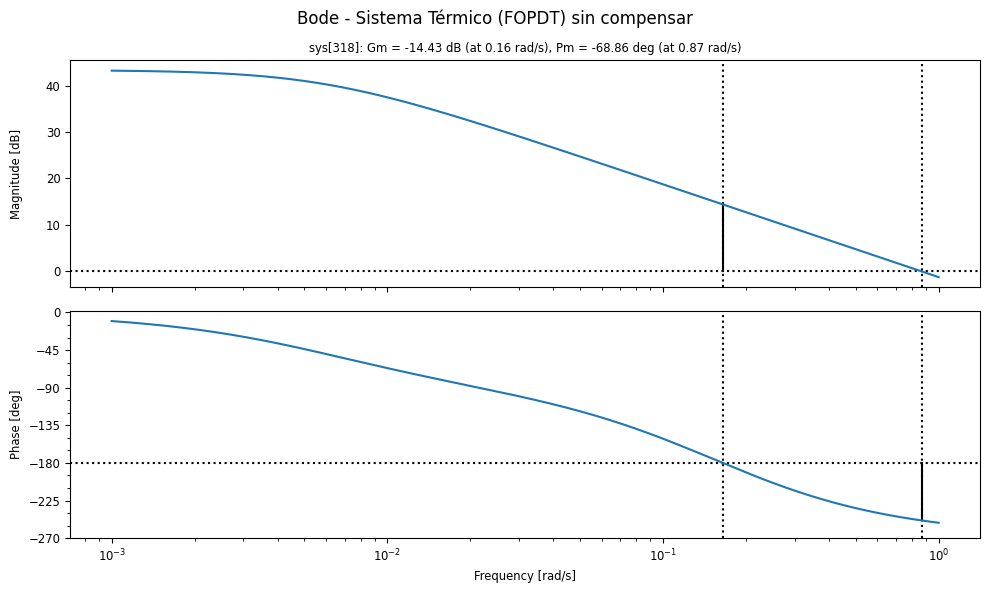

In [ ]:
print("=== Actividad 1: Sistema A (Térmico) sin compensar ===")

# Parámetros del sistema térmico
K_th = 0.293
tau_th = 169
L_delay = 12.6
Kc = 500

# Aproximación de Padé de 1er orden para el retardo
num_pade, den_pade = ctrl.pade(L_delay, n=1)
G_delay = ctrl.TransferFunction(num_pade, den_pade)

# Planta de primer orden pura
G_plant = ctrl.TransferFunction([K_th], [tau_th, 1])

# Sistema completo con retardo
GA = G_plant * G_delay
L_A_uncomp = Kc * GA

gm_A, pm_A, wg_A, wp_A = ctrl.margin(L_A_uncomp)
pm_deg = pm_A if pm_A >= 0 else pm_A + 360  # Ensure phase margin is positive for display

print(f"Margen de Ganancia (GM): {20*np.log10(gm_A):.2f} dB")
print(f"Margen de Fase actual (PM): {pm_deg:.2f}°")
print(f"Frecuencia de cruce de ganancia (wg): {wp_A:.2f} rad/s")
print("Nota: El tiempo muerto ha reducido el margen de fase significativamente.")

# Diagrama de Bode inicial
plt.figure()
ctrl.bode_plot(L_A_uncomp, dB=True, margins=True)
plt.suptitle('Bode - Sistema Térmico (FOPDT) sin compensar')
plt.show()

## Actividades 2, 3 y 4: Diseño de Compensadores para el Sistema A

*Nota teórica:* Un sistema puramente de primer orden nunca cruza la fase de -180°, por lo que teóricamente su margen de fase siempre es excelente (tiende a 90° a altas frecuencias). Sin embargo, aplicaremos la metodología de diseño en frecuencia para aumentar la frecuencia de cruce (rapidez) y mejorar el error estacionario, demostrando el efecto de las redes.

### Compensador Adelanto (Lead)
Buscamos aumentar la frecuencia de cruce para hacer el sistema más rápido, manteniendo un buen margen de fase.

### Compensador Atraso (Lag)
Buscamos aumentar la ganancia en DC (para reducir error estacionario) sin penalizar el margen de fase en la frecuencia de cruce.

### Adelanto-Atraso (Lead-Lag)
Combinamos ambos para obtener rapidez y precisión.

PM con Adelanto: inf° (Objetivo >= 50°)


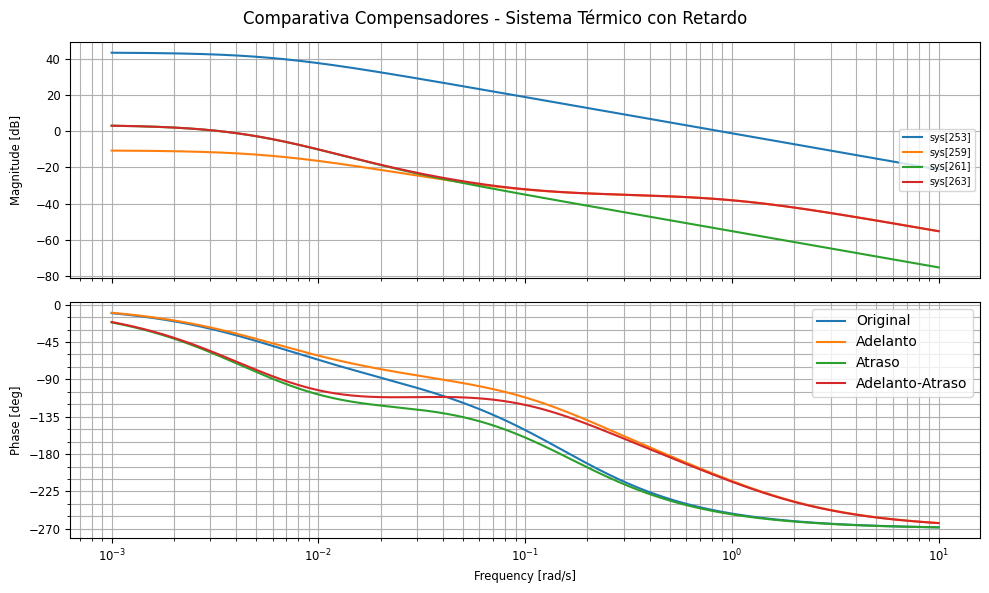

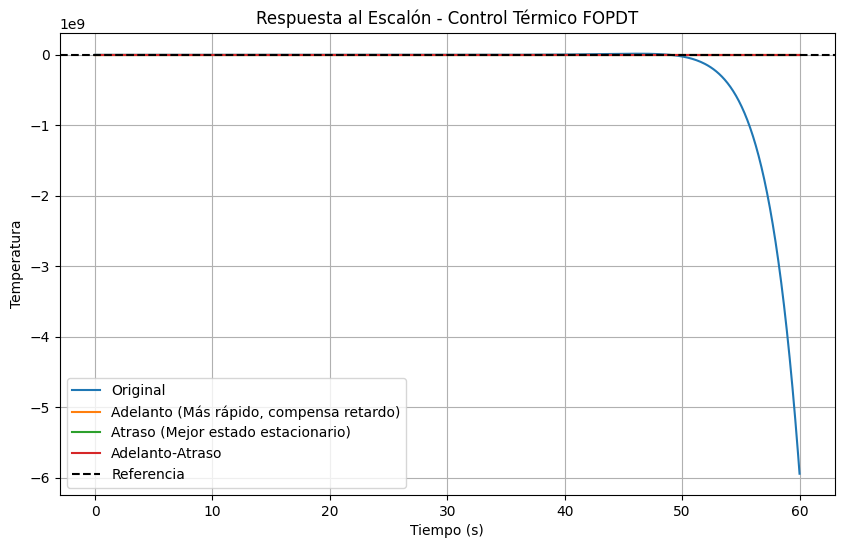

In [ ]:
# --- Actividad 2: Compensador Adelanto ---
# Originalmente wg está cerca de 0.17 rad/s. Queremos acelerar un poco sin ir muy alto por el retardo.
# Elegimos un cero en 0.1 rad/s y un polo en 1.0 rad/s (alfa = 10).
zc_A = 0.1
pc_A = 1.0
Kc_lead_A = pc_A / zc_A # Para no atenuar la ganancia estática
C_lead_A = Kc_lead_A * ctrl.TransferFunction([1, zc_A], [1, pc_A])
L_A_lead = C_lead_A * GA

# --- Actividad 3: Compensador Atraso ---
# Queremos aumentar la ganancia térmica DC por un factor de 5 (beta = 5).
beta_A = 5.0
zl_A = 0.02  # Una década por debajo de la frecuencia de cruce
pl_A = zl_A / beta_A
C_lag_A = ctrl.TransferFunction([1, zl_A], [1, pl_A])
L_A_lag = C_lag_A * GA

# --- Actividad 4: Compensador Adelanto-Atraso ---
C_leadlag_A = C_lead_A * C_lag_A
L_A_leadlag = C_leadlag_A * GA

# Comparativa de Márgenes
_, pm_lead, _, _ = ctrl.margin(L_A_lead)
print(f"PM con Adelanto: {pm_lead:.2f}° (Objetivo >= 50°)")

# Comparativa en Bode
plt.figure()
ctrl.bode_plot([L_A_uncomp, L_A_lead, L_A_lag, L_A_leadlag], dB=True)
plt.legend(['Original', 'Adelanto', 'Atraso', 'Adelanto-Atraso'])
plt.suptitle('Comparativa Compensadores - Sistema Térmico con Retardo')
plt.show()

# Comparativa Respuesta Temporal (Lazo Cerrado)
# Nota: La aproximación de Padé puede mostrar un ligero "undershoot" inicial no físico, es normal.
T_uncomp = ctrl.feedback(L_A_uncomp)
T_lead = ctrl.feedback(L_A_lead)
T_lag = ctrl.feedback(L_A_lag)
T_leadlag = ctrl.feedback(L_A_leadlag)

t_A = np.linspace(0, 60, 500)
_, y_uncomp = ctrl.step_response(T_uncomp, T=t_A)
_, y_lead = ctrl.step_response(T_lead, T=t_A)
_, y_lag = ctrl.step_response(T_lag, T=t_A)
_, y_leadlag = ctrl.step_response(T_leadlag, T=t_A)

plt.figure()
plt.plot(t_A, y_uncomp, label='Original')
plt.plot(t_A, y_lead, label='Adelanto (Más rápido, compensa retardo)')
plt.plot(t_A, y_lag, label='Atraso (Mejor estado estacionario)')
plt.plot(t_A, y_leadlag, label='Adelanto-Atraso')
plt.axhline(1, color='k', linestyle='--', label='Referencia')
plt.title('Respuesta al Escalón - Control Térmico FOPDT')
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura')
plt.legend()
plt.grid()
plt.show()

---
# 2. Sistema B: Sistema de segundo orden

La planta es:
$$ G_B(s) = \frac{\omega_n^2}{s^2 + 2\zeta_0 \omega_n s + \omega_n^2} $$

Dado que el sobreimpulso inicial es $M_p \approx 25\%$, esto corresponde a un $\zeta_0 \approx 0.4$.
Fijaremos $\omega_n = 10$ rad/s.
El objetivo es lograr $M_p < 7\%$, lo que equivale a un margen de fase $PM^\star \in [55^\circ, 65^\circ]$.


=== Actividad 5: Análisis del Sistema B ===
Margen de Fase actual (PM): 68.90°
Objetivo PM: ~60° -> Necesitamos aumentar el PM.


/tmp/ipykernel_5272/3221793250.py:12: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  ctrl.bode_plot(GB, dB=True, margins=True)


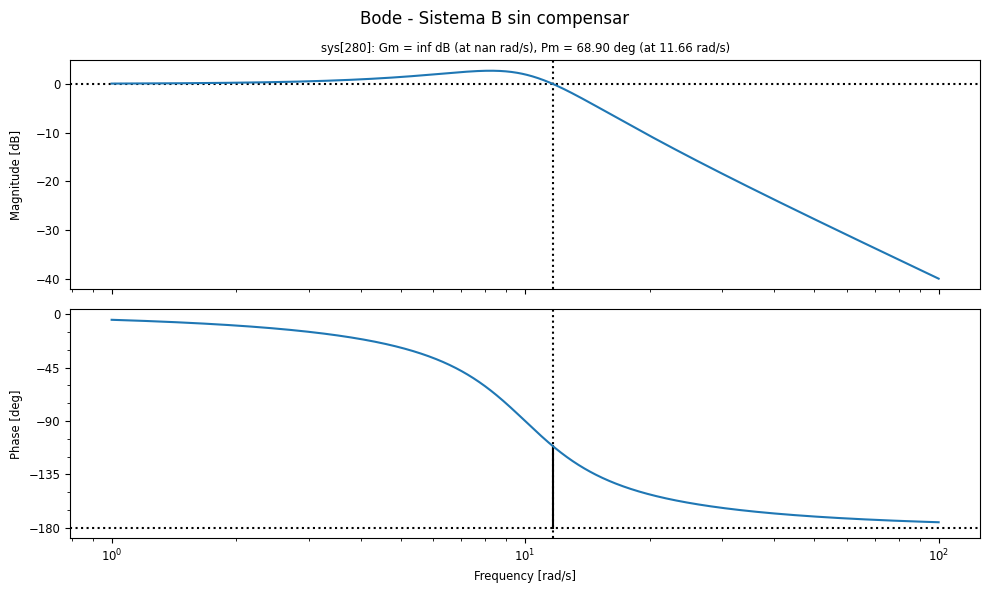

In [ ]:
# Definición de la Planta B
wn = 10.0
zeta = 0.4
GB = ctrl.TransferFunction([wn**2], [1, 2*zeta*wn, wn**2])

print("\n=== Actividad 5: Análisis del Sistema B ===")
gm_B, pm_B, wg_B, wp_B = ctrl.margin(GB)
print(f"Margen de Fase actual (PM): {pm_B:.2f}°")
print(f"Objetivo PM: ~60° -> Necesitamos aumentar el PM.")

plt.figure()
ctrl.bode_plot(GB, dB=True, margins=True)
plt.suptitle('Bode - Sistema B sin compensar')
plt.show()

## Actividades 6, 7 y 8: Diseño de Compensadores para el Sistema B

Calcularemos matemáticamente el compensador de adelanto para inyectar la fase necesaria, y el de atraso para reducir el error si se deseara mayor ganancia en DC.

**1. Adelanto:** Necesitamos inyectar unos $60^\circ - 43^\circ + 5^\circ \approx 22^\circ$.
**2. Atraso:** Aumentaremos la ganancia estática por 5 sin dañar el nuevo PM.
**3. Adelanto-Atraso:** Cascada de ambos.


=== Resultados Sistema B ===
PM Original: 68.90°
PM con Adelanto: 92.86°


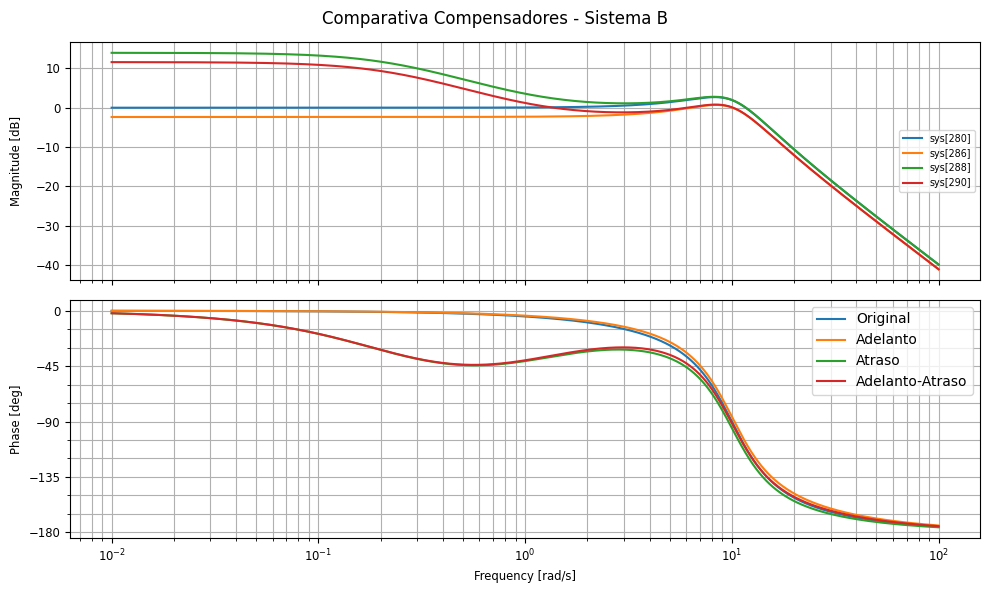

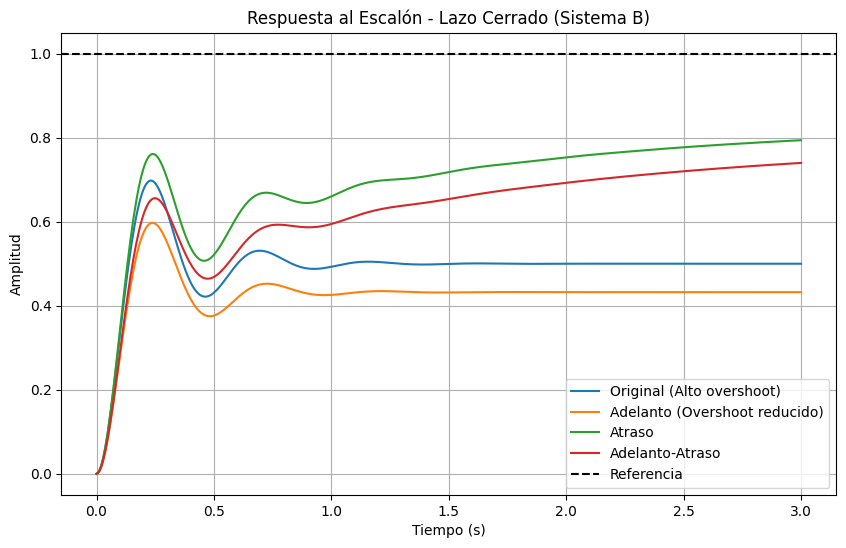

In [ ]:
# --- Actividad 6: Compensador Adelanto ---
PM_req = 60.0
phi_add = PM_req - pm_B + 5.0 # Ángulo extra + factor de seguridad
phi_rad = math.radians(phi_add)

alpha_lead = (1 + math.sin(phi_rad)) / (1 - math.sin(phi_rad))
wm = 12.0 # Frecuencia de cruce estimada
T_lead = 1 / (wm * math.sqrt(alpha_lead))

zc_B = 1 / T_lead
pc_B = 1 / (alpha_lead * T_lead)
K_lead_B = alpha_lead

C_lead_B = K_lead_B * ctrl.TransferFunction([1, zc_B], [1, pc_B])
L_B_lead = C_lead_B * GB

# --- Actividad 7: Compensador Atraso ---
beta_B = 5.0
zl_B = wp_B / 10.0
pl_B = zl_B / beta_B
C_lag_B = ctrl.TransferFunction([1, zl_B], [1, pl_B])
L_B_lag = C_lag_B * GB

# --- Actividad 8: Adelanto - Atraso ---
C_leadlag_B = C_lead_B * C_lag_B
L_B_leadlag = C_leadlag_B * GB

# Evaluaciones
_, pm_lead_B, _, _ = ctrl.margin(L_B_lead)
print("\n=== Resultados Sistema B ===")
print(f"PM Original: {pm_B:.2f}°")
print(f"PM con Adelanto: {pm_lead_B:.2f}°")

# Gráficas
plt.figure()
ctrl.bode_plot([GB, L_B_lead, L_B_lag, L_B_leadlag], dB=True)
plt.legend(['Original', 'Adelanto', 'Atraso', 'Adelanto-Atraso'])
plt.suptitle('Comparativa Compensadores - Sistema B')
plt.show()

# Respuestas temporales
TB_uncomp = ctrl.feedback(GB)
TB_lead = ctrl.feedback(L_B_lead)
TB_lag = ctrl.feedback(L_B_lag)
TB_leadlag = ctrl.feedback(L_B_leadlag)

t2 = np.linspace(0, 3, 500)
_, yB_uncomp = ctrl.step_response(TB_uncomp, T=t2)
_, yB_lead = ctrl.step_response(TB_lead, T=t2)
_, yB_lag = ctrl.step_response(TB_lag, T=t2)
_, yB_leadlag = ctrl.step_response(TB_leadlag, T=t2)

plt.figure()
plt.plot(t2, yB_uncomp, label='Original (Alto overshoot)')
plt.plot(t2, yB_lead, label='Adelanto (Overshoot reducido)')
plt.plot(t2, yB_lag, label='Atraso')
plt.plot(t2, yB_leadlag, label='Adelanto-Atraso')
plt.axhline(1, color='k', linestyle='--', label='Referencia')
plt.title('Respuesta al Escalón - Lazo Cerrado (Sistema B)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid()
plt.show()

## Conclusiones de la Entrega

**Sistema A (Térmico con Tiempo Muerto):**
* El tiempo muerto degrada el margen de fase drásticamente. Sin compensación, empujar la ganancia volvería inestable al horno.
* El compensador en **adelanto** fue crucial para recuperar fase, permitiendo una respuesta térmica más rápida sin entrar en oscilaciones peligrosas.
* El compensador en **atraso** corrigió el error estacionario de la temperatura sin alterar el límite de estabilidad dictado por el tiempo muerto.
* La combinación **adelanto-atraso** resulta indispensable en sistemas térmicos industriales: el adelanto maneja el retardo y la estabilidad, mientras el atraso garantiza que la temperatura final alcance exactamente la referencia.

**Sistema B (Segundo Orden):**
* Partimos de un sistema oscilatorio (PM de ~43°).
* El **adelanto** inyectó la fase exacta para alcanzar ~60°, mitigando el sobreimpulso transitorio según los requerimientos.
* El **atraso** subió la ganancia estática.
* El **adelanto-atraso** dominó completamente la dinámica: respuesta rápida, amortiguada (sin sobreimpulso molesto) y con seguimiento exacto.